# 📉 Customer Churn Prediction

Predicting customer churn using Machine Learning and Random Forest Classifier.

# 1-Import Libraries

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


# 2-Load Dataset

In [9]:
data=pd.read_csv('Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3-Data Exploration

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
data.duplicated().sum()

0

In [13]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# 4-Data Preprocessing

In [17]:
le=LabelEncoder()
binary_cols = ["Partner","Dependents","PhoneService","OnlineSecurity",
               "OnlineBackup","DeviceProtection","TechSupport",
               "StreamingTV","StreamingMovies","PaperlessBilling","Churn"]
for col in binary_cols:
    data[col] = data[col].astype(str).str.strip().str.lower()
    data[col] = data[col].map({'yes': 1, 'no': 0})
object_cols=["customerID","gender","MultipleLines","InternetService","Contract","PaymentMethod"]
for col in object_cols:
    data[col]=le.fit_transform(data[col])

In [18]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
print(data["TotalCharges"].isnull().sum())


11


# 5-Feature Selection

In [19]:
x=data.drop("Churn",axis=1)
y=data["Churn"]

# 6-Train-Test Split

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2,
                                               random_state=42)

# 7-Model Training and Prediction

In [21]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
model.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=500, random_state=42)

In [22]:
 y_pred=model.predict(x_test)

# 8-Model Evaluation

In [23]:

acc = accuracy_score(y_test, y_pred)

print("Accuracy =", acc)

Accuracy = 0.7913413768630234


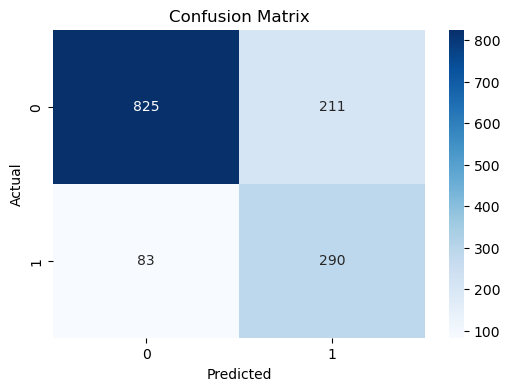

In [24]:


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1036
           1       0.58      0.78      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.79      0.76      1409
weighted avg       0.82      0.79      0.80      1409



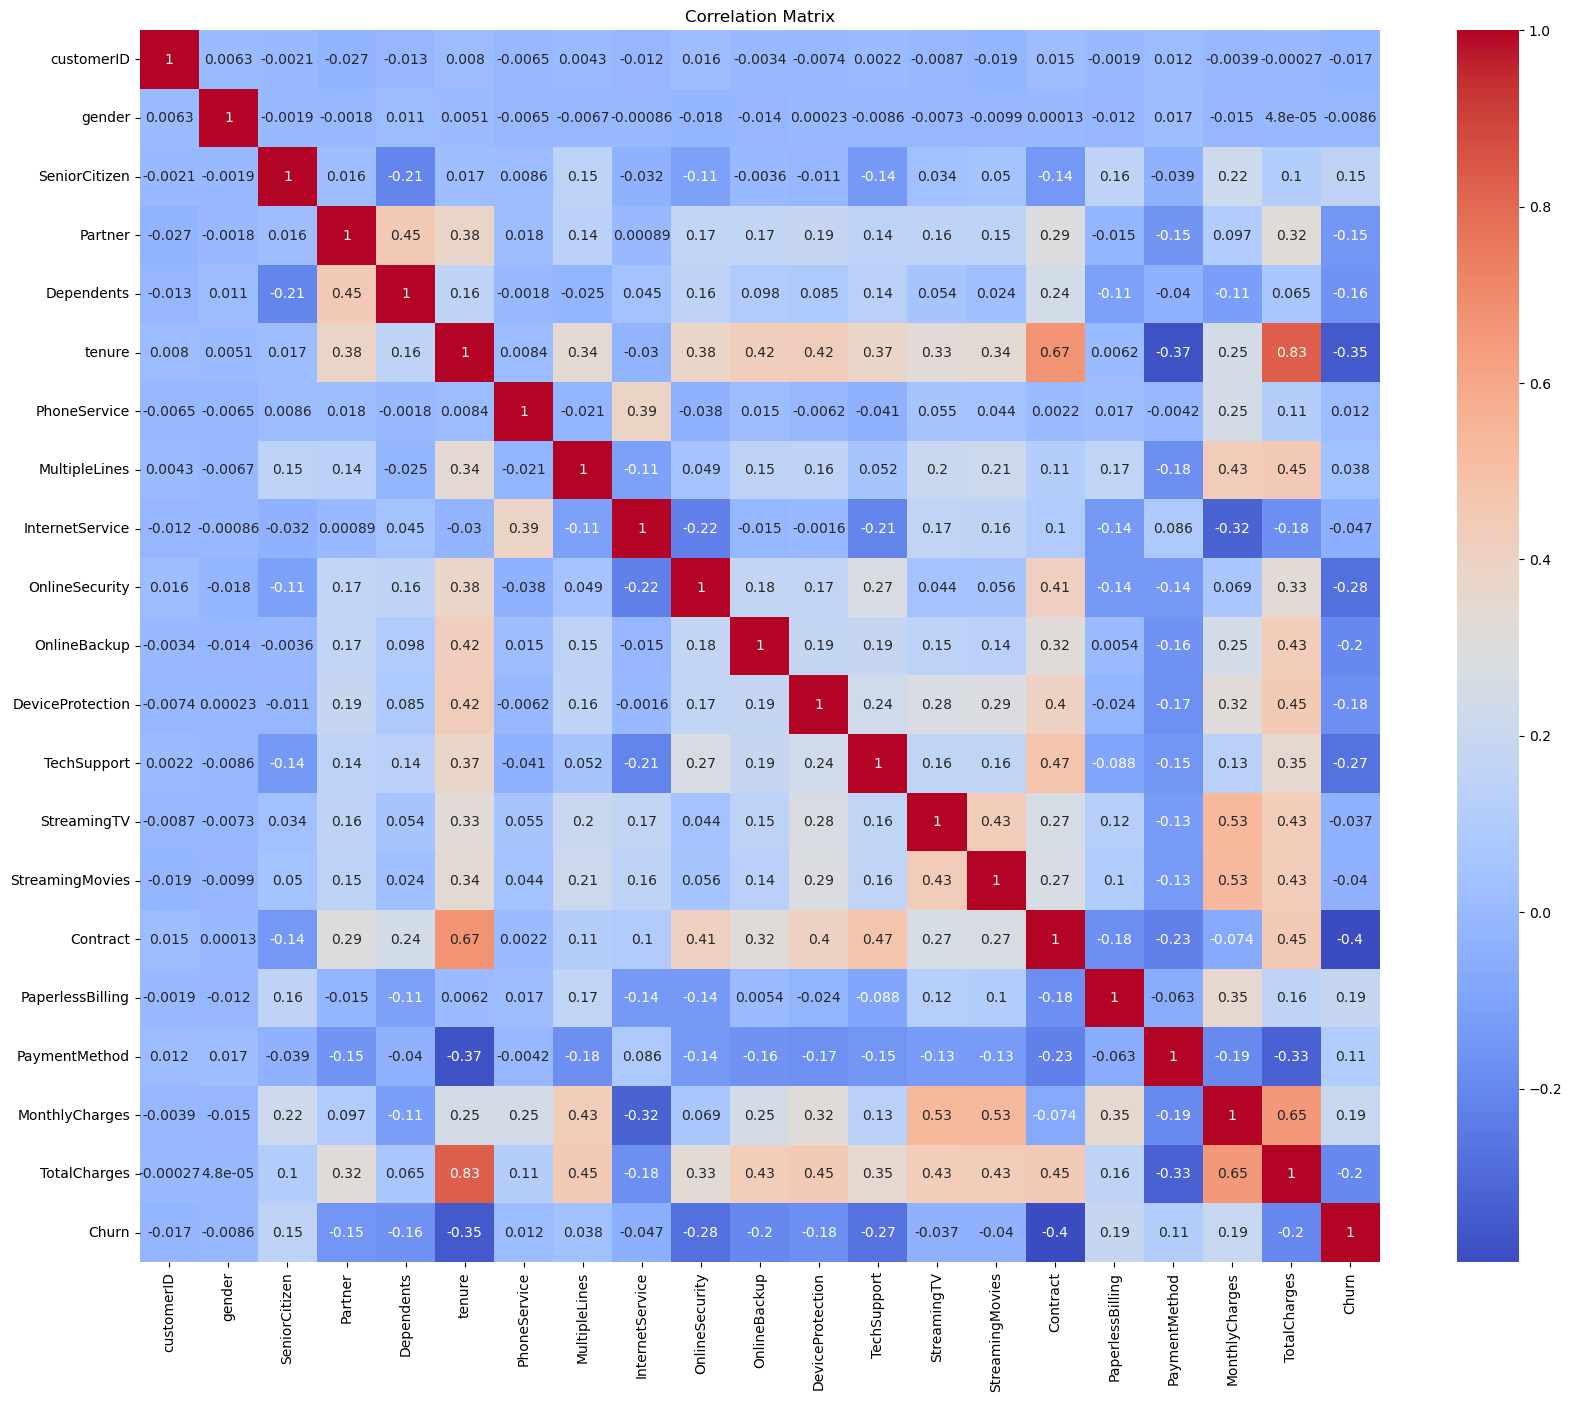

In [31]:
plt.figure(figsize=(20,16))
sns.heatmap(data.corr(),annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 9-Feature Importance

In [34]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

            Feature  Importance
15         Contract    0.175731
5            tenure    0.152437
19     TotalCharges    0.115331
18   MonthlyCharges    0.096887
9    OnlineSecurity    0.079724
12      TechSupport    0.071227
0        customerID    0.060667
8   InternetService    0.050092
17    PaymentMethod    0.032941
10     OnlineBackup    0.030152


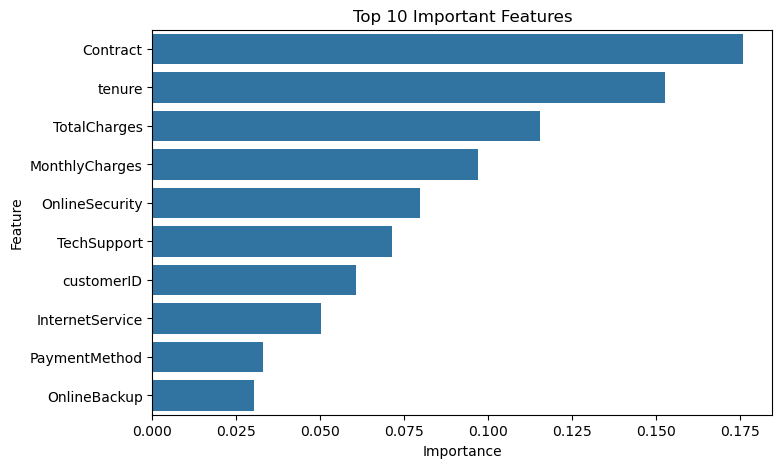

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

# 10-Churn Distribution 

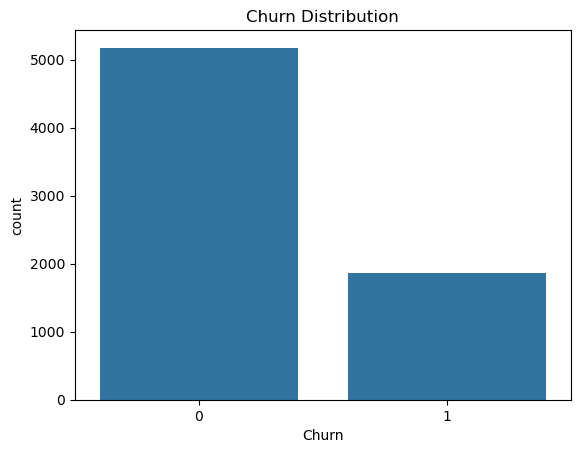

In [33]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

# 11-Business Insights

- Customers with month-to-month contracts are more likely to churn.
- Customers with higher monthly charges tend to leave more frequently.
- Contract type is one of the strongest predictors of churn.
- The model achieved approximately 79% accuracy with a churn recall of 78%.

# 🏁 Conclusion

This project demonstrates how machine learning can be used to identify customers at risk of leaving a company. Early detection of churn allows businesses to take proactive actions and improve customer retention.